# Layered vs homogeneous Green's functions and synthetic inversion

This notebook compares **layered elastic** and **homogeneous half-space** Green's functions for the same GeoSlip2D interface geometry.

## Learning goals
- Build two Green's-function operators on the same geometry and observation grid.
- Forward model simple slip scenarios and compare predicted surface velocities.
- Generate synthetic observations from a chosen 'true' model.
- Invert the same synthetic data with both operators and compare fit and recovered slip.

## Prerequisites
- `geoslip2d`, `numpy`, and `matplotlib` are available in the active Python environment.
- Run from the GeoSlip2D repository (or one level below) so paths resolve correctly.

## Suggested run order
1. Run all cells once from top to bottom.
2. For parameter experiments, rerun from the section you changed through the end.
3. If you change geometry or layer parameters, rerun from Section 1.

![Interface Geometry](./images/layered_interface.png)

In [ ]:
# import standard libraries
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import geoslip2d as gs2d

# Helper routines for forward modeling, plotting, and inversion comparisons.
from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)

# Resolve project root robustly whether running from repo root or notebook folder.
cwd = Path.cwd().resolve()
if (cwd / "src" / "geoslip2d").is_dir():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = cwd.parent

OUTPUT_DIR = PROJECT_ROOT / "examples" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

PROJECT_ROOT = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D
OUTPUT_DIR   = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D/examples/outputs


## 1. Shared interface geometry and observation grid

Both Green's-function models in this notebook use the same `InterfaceGeometry` and the same surface observation coordinates `xobs`.

What to check in this section:
- Geometry shape and patching are reasonable.
- Observation window (`xobs`) covers the area of interest for comparison.

InterfaceGeometry(n_patch=49, x=[0, 240] km, z=[-0, 45.8] km)


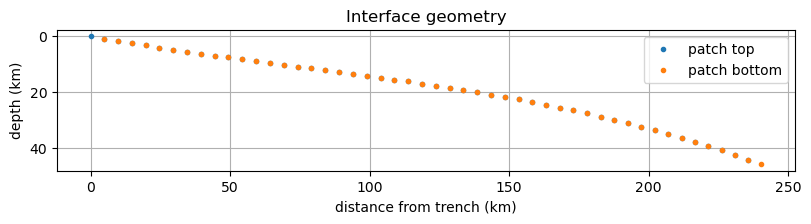

In [ ]:
# Shared interface and observation grid used by both model backends.
faultdip_trench = 10.0
faultdip_bottom = 20.0
x_trench = 0.0
x_bottom = 238.0
z_bottom = 45.0
patch_length = 5.0

# Surface observation coordinates (km)
# Note the layered solution will not be accurate within ~25 km of the trench
xobs = np.linspace(150, 400.0, 300)

interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=faultdip_trench,
    x_trench=x_trench,
    x_bottom=x_bottom,
    faultdip_bottom=faultdip_bottom,
    z_bottom=z_bottom,
    patch_length=patch_length,
 )
print(interface.summary())
fig = gs2d.plot_interface(interface)
plt.show()

## 2. Build homogeneous and layered Green's functions

This section constructs two Green's kernel operators on the same interface and observation grid:

- Homogeneous: reference elastic half-space model.
- Layered: depth-dependent shear modulus model (`h`, `mu`, `nu`).

Interpretation note: differences between these operators reflect Earth-structure assumptions, not geometry differences.

In [ ]:
# Build homogeneous reference Green's functions.
greens_hom = gs2d.build_greens(
    "homogeneous",
    interface,
    xobs,
    length_override=patch_length,
    progress=True,
)

# Build layered Green's functions (h: layer thicknesses; mu/nu: material properties).
# Note: shear moduli, (mu), are relative, so only ratios matter. 
layered_cfg = gs2d.LayeredConfig(
    h=np.array([5.0, 10.0, 15.0]),
    mu=np.array([0.1, 3.0, 5.0, 10.0]),
    nu=np.array([0.25, 0.25, 0.25, 0.25]),
    progress=True,
)

greens_nonhom = gs2d.build_greens(
    "layered",
    interface,
    xobs,
    layered_cfg,
)

completed 1 of 49 patches
completed 2 of 49 patches
completed 3 of 49 patches
completed 4 of 49 patches
completed 5 of 49 patches
completed 6 of 49 patches
completed 7 of 49 patches
completed 8 of 49 patches
completed 9 of 49 patches
completed 10 of 49 patches
completed 11 of 49 patches
completed 12 of 49 patches
completed 13 of 49 patches
completed 14 of 49 patches
completed 15 of 49 patches
completed 16 of 49 patches
completed 17 of 49 patches
completed 18 of 49 patches
completed 19 of 49 patches
completed 20 of 49 patches
completed 21 of 49 patches
completed 22 of 49 patches
completed 23 of 49 patches
completed 24 of 49 patches
completed 25 of 49 patches
completed 26 of 49 patches
completed 27 of 49 patches
completed 28 of 49 patches
completed 29 of 49 patches
completed 30 of 49 patches
completed 31 of 49 patches
completed 32 of 49 patches
completed 33 of 49 patches
completed 34 of 49 patches
completed 35 of 49 patches
completed 36 of 49 patches
completed 37 of 49 patches
completed 

## 3. Forward model: uniform backslip above locking depth

Here we apply a simple synthetic slip distribution (uniform backslip above a locking depth) and compare predicted surface velocities for the two Earth models.

Use this section to build intuition before inversion.

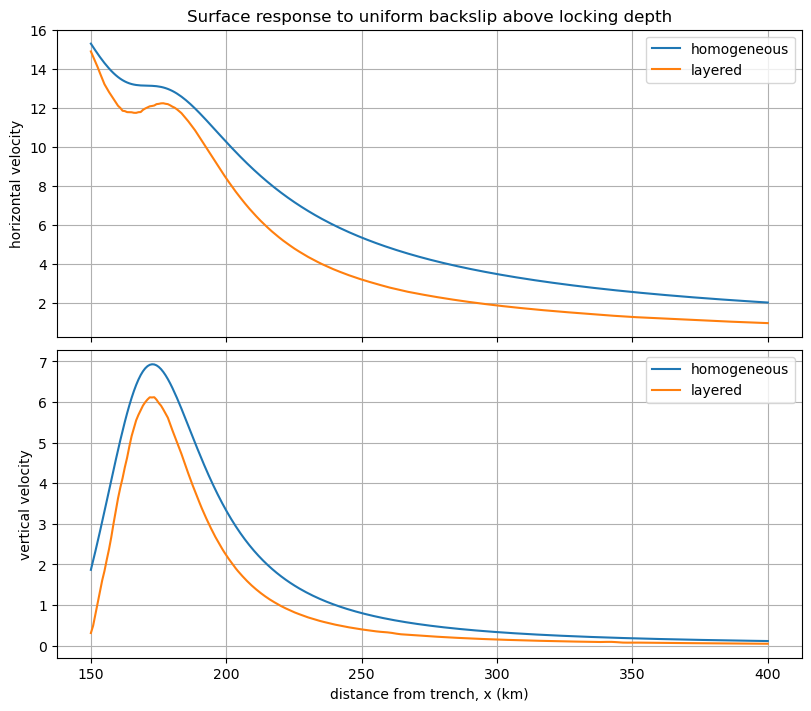

In [ ]:
# Uniform backslip above locking depth (simple reference scenario).
locking_depth_km = 25.0

slip_hom = uniform_backslip_above_depth(greens_hom, locking_depth_km, backslip_rate=30.0)
slip_nonhom = uniform_backslip_above_depth(greens_nonhom, locking_depth_km, backslip_rate=30.0)

vel_hom = surface_velocity(greens_hom, slip_hom)
vel_nonhom = surface_velocity(greens_nonhom, slip_nonhom)

fig = plot_surface_velocities(xobs, vel_hom, vel_nonhom, "layered")
plt.show()

## Optional slip distribution: Cascadia-like slow-slip scenario

Modify depth range and slip magnitude in the next cell to test how a localized slow-slip source changes predicted velocities in homogeneous vs layered models.

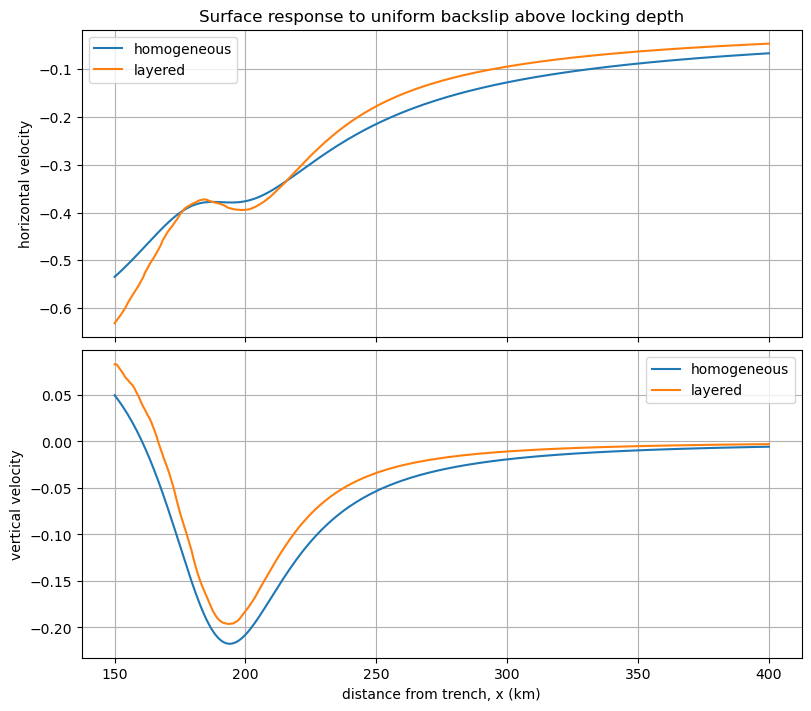

In [ ]:
# Localized slow-slip patch between selected depths.
depths = patch_center_depths(greens_hom)
upper_depth_km = 10
lower_depth_km = 30
slip_mag = -1  # cm; negative indicates forward slip in this sign convention.
slip_ss = slip_mag * ((depths <= lower_depth_km) & (depths >= upper_depth_km)).astype(float)

# Compute and compare surface velocities for the same slip in each Earth model.
vel_hom_ss = surface_velocity(greens_hom, slip_ss)
vel_nonhom_ss = surface_velocity(greens_nonhom, slip_ss)

fig = plot_surface_velocities(xobs, vel_hom_ss, vel_nonhom_ss, "layered")
plt.show()

## 4. Synthetic inversion and model comparison

Synthetic data are generated from the **layered** model and inverted twice:

- with homogeneous Green's functions
- with layered Green's functions

Interpretation tips:
- Compare WRMS values to evaluate data fit.
- Compare recovered slip to the prescribed truth model.
- Noise level (`sigma_h`, `sigma_v`) and regularization (`alpha`) affect smoothness and fit.

In [ ]:
# Local helper for synthetic profile observations used in the inversion section.
# This is intentionally notebook-local so users can tweak noise/model choices here.
def make_synthetic_observations(greens_truth, slip_truth, sigma_h=0.02, sigma_v=0.02, noise=False, seed=7):
    vh, vv = surface_velocity(greens_truth, slip_truth)
    rng = np.random.default_rng(seed)
    if noise:
        vh = vh + rng.normal(0.0, sigma_h, size=vh.size)
        vv = vv + rng.normal(0.0, sigma_v, size=vv.size)
    return gs2d.ProfileObservations(
        x_hor=greens_truth.xobs,
        v_hor=vh,
        sig_hor=np.full_like(vh, sigma_h, dtype=float),
        x_vert=greens_truth.xobs,
        v_vert=vv,
        sig_vert=np.full_like(vv, sigma_v, dtype=float),
        metadata={"truth_backend": greens_truth.source_type},
    )

Homogeneous inversion WRMS:     1.568
Non-homogeneous inversion WRMS: 0.924


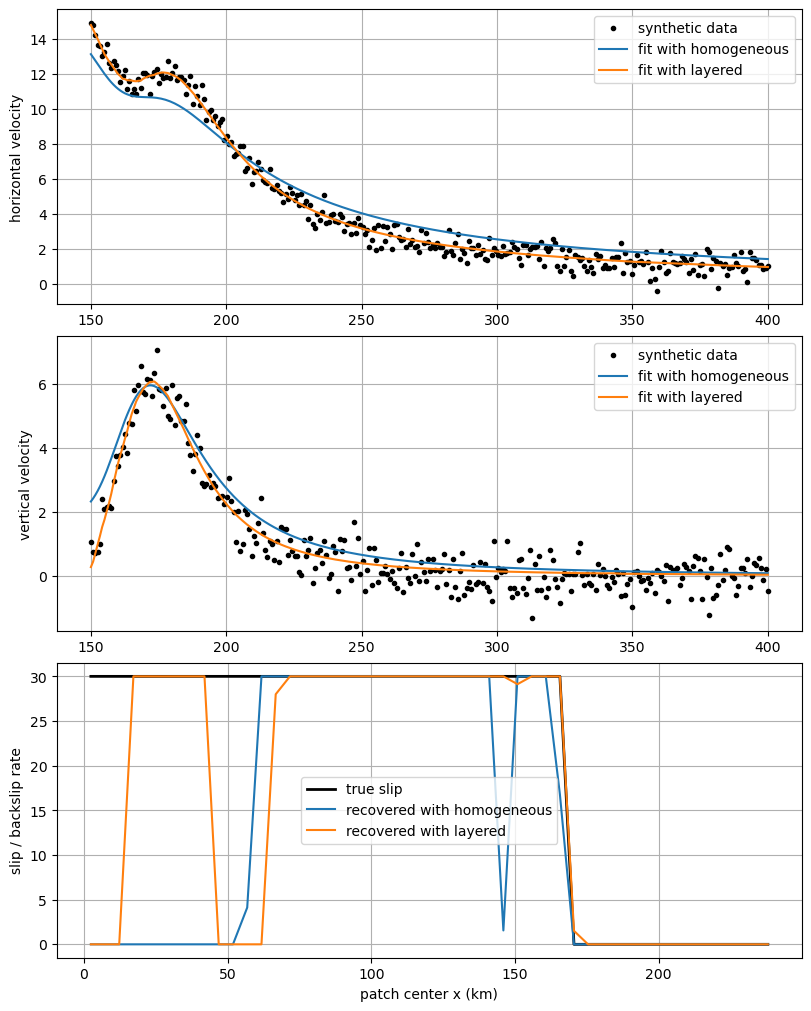

In [ ]:
# Generate synthetic observations and invert with both homogeneous and layered operators.

true_slip = slip_nonhom.copy()
# true_slip = slip_ss.copy()  # Alternate truth model from the slow-slip exercise.

observations = make_synthetic_observations(
    greens_nonhom,
    true_slip,
    sigma_h=0.5,  # mm/yr standard deviation for horizontal noise
    sigma_v=0.5,  # mm/yr standard deviation for vertical noise
    noise=True,
)

# Slip inversion configuration. Adjust regularization and solver settings here to see how they affect the results.
cfg = gs2d.SlipInversionConfig(
    alpha=2,
    smoothing_order="none",  # "first", "second", or "none"
    solver_type="bounded",  # "unbounded", "nonnegative", or "bounded"
    inversion_mode="slip_deficit",  # "forward_slip" or "slip_deficit"
    use_vertical=True,
)

# example of how to implement a uniform upper bound for solver_type="bounded"
#cfg.upper_bound = 30;

# Conduct slip inversions using both Green's function sets and compare results.
out_hom = gs2d.fit_profile_slip(observations, greens_hom, cfg)
out_nonhom = gs2d.fit_profile_slip(observations, greens_nonhom, cfg)

print(f"Homogeneous inversion WRMS:     {out_hom['wrms']:.3f}")
print(f"Non-homogeneous inversion WRMS: {out_nonhom['wrms']:.3f}")

# plot results
fig = plot_inversion_results(
    greens_hom,
    greens_nonhom,
    true_slip,
    out_hom,
    out_nonhom,
    "layered",
)
plt.show()